In [1]:
import numpy as np
import matplotlib.pyplot as plt
import specula
specula.init(-1)  # CPU execution
from specula.data_objects.iir_filter_data import IirFilterData

Cupy import successfull. Installed version is: 13.6.0
Default device is CPU


In [2]:
def optimize_predictive_controller(e_meas_prime, p, q, lam=0.99):
    """
    Optimizes a, b filter coefficients using the modified RLS algorithm.
    
    Args:
        e_meas_prime: Open-loop measurements (recovered from closed-loop if needed).
        p: Number of 'b' parameters + 1 (denominator).
        q: Number of 'a' parameters (numerator).
        lam: Forgetting factor (typically close to 1).
        
    Returns:
        theta: Vector [b1...bp-1, a0...aq-1]
    """
    N = len(e_meas_prime)
    num_params = (p - 1) + q
    
    # Initialize parameters
    theta = np.zeros(num_params)
    P = np.eye(num_params) * 100.0  # Covariance matrix initialization
    y_alg = np.zeros(N)
    
    # phi contains: [y_alg(i-1)...y_alg(i-p+1), (y_alg-e_meas')(i-2)...]
    phi = np.zeros(num_params)

    for i in range(2, N):
        # 1. Update the regressor vector phi(i) based on Eq. 22
        # Shift b-related history (y_alg)
        for j in range(p - 1):
            if i - 1 - j >= 0:
                phi[j] = y_alg[i - 1 - j]
        
        # Shift a-related history (y_alg - e_meas_prime)
        for j in range(q):
            if i - 2 - j >= 0:
                phi[p - 1 + j] = y_alg[i - 2 - j] - e_meas_prime[i - 2 - j]

        # 2. RLS Gain Update
        # Using standard RLS update equations derived from Eq. 22
        denom = lam + phi.T @ P @ phi
        K = (P @ phi) / denom
        
        # 3. Predict error and update theta
        # epsilon_alg = e_meas_prime(i) + theta^T * phi
        eps = e_meas_prime[i] + (theta @ phi)
        theta = theta - K * eps
        
        # 4. Update Covariance Matrix
        P = (P - np.outer(K, phi.T @ P)) / lam
        
        # 5. Compute current estimated loop output y_alg(i) = -theta^T * phi
        y_alg[i] = -theta @ phi

    return theta

def psd_to_timeseries(psd, fs):
    """
    Generates a time series from a one-sided PSD.
    
    Args:
        psd (array): The one-sided power spectral density values.
        fs (float): Sampling frequency in Hz.
        
    Returns:
        timeseries (array): The generated real-valued time series.
    """
    n_freqs = len(psd)
    n_samples = 2 * (n_freqs - 1)  # Total samples for irfft
    df = fs / n_samples             # Frequency resolution

    # 1. Convert PSD to Amplitude Spectrum
    # Power = (Amplitude^2) / (2 * df). So Amplitude = sqrt(2 * psd * df)
    # Note: DC (index 0) and Nyquist don't get the factor of 2 in standard scaling
    amplitudes = np.sqrt(psd * df)
    amplitudes[1:-1] *= np.sqrt(2) 

    # 2. Generate Random Phases (0 to 2*pi)
    # DC and Nyquist should have zero phase for a real signal
    phases = np.random.uniform(0, 2 * np.pi, n_freqs)
    phases[0] = 0
    phases[-1] = 0

    # 3. Construct Complex Spectrum
    complex_spectrum = amplitudes * np.exp(1j * phases)

    # 4. Inverse FFT to get Time Series
    # irfft expects the one-sided spectrum up to Nyquist
    timeseries = np.fft.irfft(complex_spectrum, n=n_samples)
    
    # Scale back to match the original signal power
    # irfft in numpy scales by 1/n_samples by default
    return timeseries * n_samples

In [3]:

# --- Configuration ---
fs = 1000.0         # Sampling frequency [Hz]
gain = 0.5         # Loop gain
ff = 0.995          # Forgetting factor (leaky integrator)
delay_frames = 2.0  # Total loop delay [frames]
fc_lpf = 400.0      # Mirror LPF cutoff [Hz]

# 1. Define Controller (C)
controller = IirFilterData.from_gain_and_ff(gain=[gain], ff=[ff])

# 2. Define Plant Components (P)
# Delay TF: interpolates between samples for fractional values
nw_delay, dw_delay = controller.discrete_delay_tf(delay_frames)

# Mirror dynamics (2nd order Butterworth)
lpf_obj = IirFilterData.lpf_from_fc(fc=fc_lpf, fs=fs, n_ord=4)
lpf_num, lpf_den = lpf_obj.num[0], lpf_obj.den[0]

# 3. Assemble the Open Loop (CP)
# Open Loop Numerator = C_num * P_delay_num * LPF_num
nw_plant = np.convolve(nw_delay, lpf_num)
dm_plant = np.convolve(dw_delay, lpf_den)

# --- Performance Plotting ---
freq = np.logspace(-2, np.log10(fs/2), 4000)
rtf_mag = controller.RTF(mode=0, fs=fs, freq=freq, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)
ntf_mag = controller.NTF(mode=0, fs=fs, freq=freq, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)

Text(0.5, 1.0, 'DM step response\n($f_{cut}$ = 400.0 Hz)')

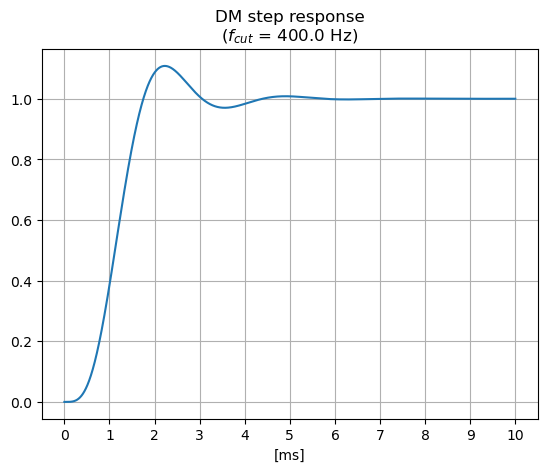

In [4]:
dt = 1e-6
T = np.arange(0, 0.01/dt) * dt
dm_obj = IirFilterData.lpf_from_fc(fc=fc_lpf, fs=1/dt, n_ord=4)
tvec,step=dm_obj.step_response(dt=dt,T=T)

plt.figure()
plt.plot(tvec*1e+3,step)
plt.xlabel('[ms]')
plt.xticks(np.arange(0,11))
plt.grid()
plt.title('DM step response\n'+r'($f_{cut}$ = '+f'{fc_lpf} Hz)')

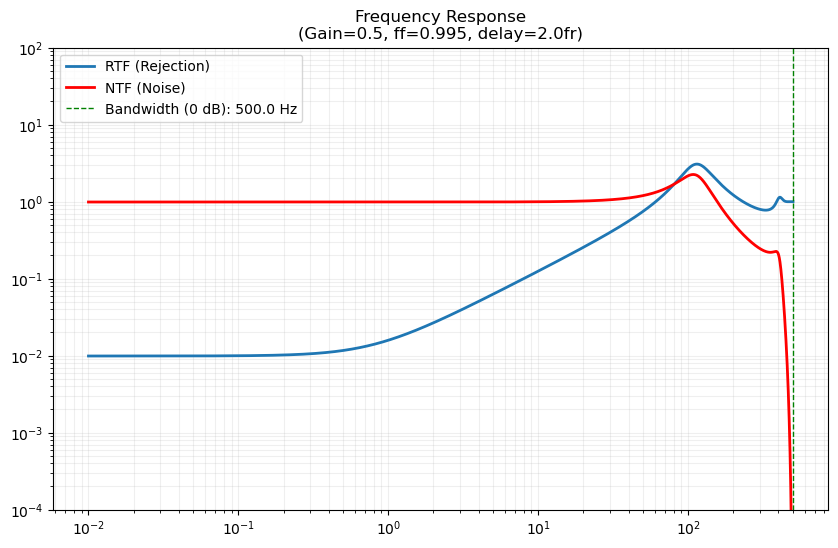

In [5]:
plt.figure(figsize=(10, 6))
plt.loglog(freq, rtf_mag, label='RTF (Rejection)', linewidth=2)
plt.loglog(freq, ntf_mag, label='NTF (Noise)', linewidth=2, color='red')
idx_cross = np.argmin(np.abs(rtf_mag - 1))
plt.axvline(freq[idx_cross], color='green', linestyle='--', linewidth=1.0,
            label=f'Bandwidth (0 dB): {freq[idx_cross]:.1f} Hz')
plt.title(f'Frequency Response\n(Gain={gain}, ff={ff}, delay={delay_frames}fr)')
plt.legend(loc='lower left')
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.ylim([1e-4,100])

# --- Stability Analysis (Nyquist) ---
ol_num = np.convolve(controller.num[0], nw_plant)
ol_den = np.convolve(controller.den[0], dm_plant)

open_loop_obj = IirFilterData(ordnum=[len(ol_num)], ordden=[len(ol_den)], num=[ol_num], den=[ol_den])

# plt.figure(figsize=(6, 6))
# open_loop_obj.nyquist_plot(dt=1/fs, unit_circle=True)

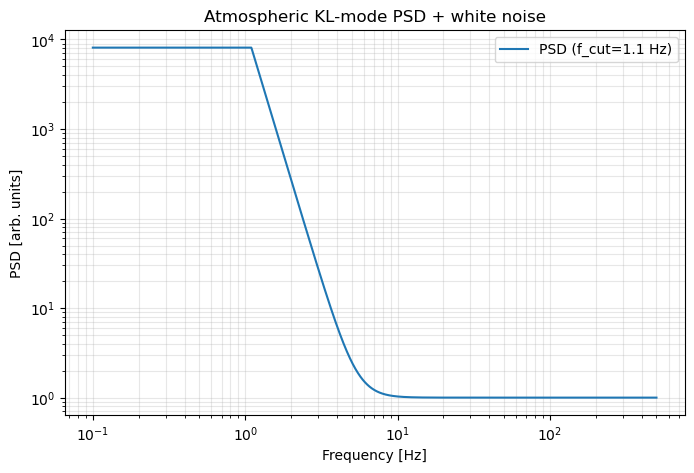

In [6]:
from scipy.integrate import simpson as simps

fs = 1000.0           # sampling frequency [Hz]
noise_floor = 1e-5    # white noise floor (arb. units)
n = 2

# frequency vector for PSD (up to Nyquist)
freq_psd = np.logspace(-1, np.log10(fs/2), 2000)

def get_zernike_spectra(f, n:int, pow:float, V:float, D:float = 8.2, noise_floor:float=0.0):
    f_cut = 0.3 * (n+1) * V / D 
    psd = np.ones_like(f)
    if n == 1:
        psd[f<=f_cut] = (f[f<=f_cut] / f_cut) ** (-2.0/3.0)
    psd[f>f_cut] = (f[f>f_cut] / f_cut) ** (-17.0/3.0)
    psd *= pow/simps(psd,f)
    psd += noise_floor**2
    return psd, f_cut

psd, f_cut = get_zernike_spectra(freq_psd, n=n, pow=1e-6, V=10, noise_floor=noise_floor)
psd /= noise_floor**2

# plot results
plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD (f_cut={f_cut:.1f} Hz)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.title('Atmospheric KL-mode PSD + white noise')
plt.grid(which='both', alpha=0.3)
plt.legend()
plt.show()

estimated theta [-1.01065324  1.00669993  0.00496099  0.1837754  -0.18801993  0.15448588]


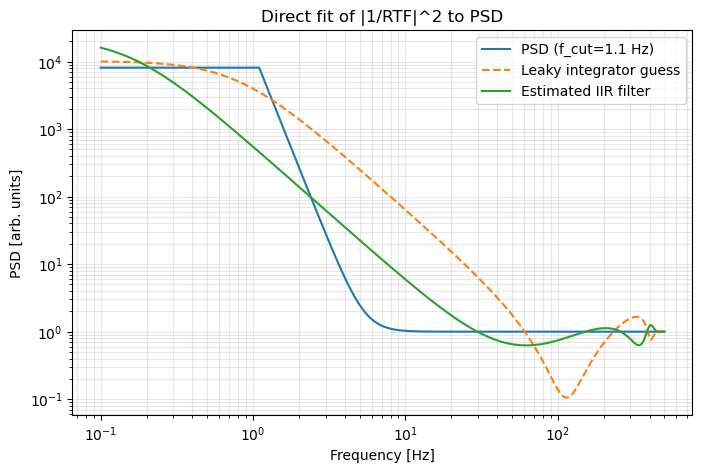

In [7]:
# --- Direct optimization of IIR coefficients to match PSD without RLS ---
from scipy.optimize import minimize

# target order same as before
p = 4+(n==1)  # denominator length
q = 3+(n==1)  # numerator length

# cost function compares log-magnitude to avoid scale issues

def iir_cost(theta):
    b = theta[: p-1]
    a = theta[p-1 :]
    filt = IirFilterData(ordnum=[len(a)], ordden=[len(b)], num=[a], den=[b])
    rtf = filt.RTF(mode=0, fs=fs, freq=freq_psd, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)
    C = 1/rtf**2
    return np.sum((np.log10(C)-np.log10(psd)) ** 2)

# initial guess from simple leaky integrator (controller)
# controller.num/den hold the leaky integrator coefficients
b_init = np.zeros(p - 1)
a_init = np.zeros(q)

# copy whatever we can from the controller, truncated or zero‑padded
b_orig = controller.den[0]
a_orig = controller.num[0]

b_init[: min(len(b_orig), len(b_init))] = b_orig[: min(len(b_orig), len(b_init))]
a_init[: min(len(a_orig), len(a_init))] = a_orig[: min(len(a_orig), len(a_init))]

init_theta = np.concatenate([b_init, a_init])

result = minimize(iir_cost, init_theta, method='Powell', options={'maxiter':1e+4, 'ftol':1e-8})

theta_est = result.x
b_est = theta_est[: p-1]
a_est = theta_est[p-1 :]
print("estimated theta", theta_est)

# compare on plot
filt_init = IirFilterData(ordnum=[len(a_init)], ordden=[len(b_init)], num=[a_init], den=[b_init])
C_init = filt_init.RTF(mode=0, fs=fs, freq=freq_psd, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)**-2 #np.abs(1 + filt_init.frequency_response(num=a_init, den=b_init, fs=fs, freq=freq_psd)) ** 2
filt_est = IirFilterData(ordnum=[len(a_est)], ordden=[len(b_est)], num=[a_est], den=[b_est])
C_est = filt_est.RTF(mode=0, fs=fs, freq=freq_psd, dm=dm_plant, nw=nw_plant, dw=1.0, plot=False)**-2 #np.abs(1 + filt_est.frequency_response(num=a_est, den=b_est, fs=fs, freq=freq_psd)) ** 2

plt.figure(figsize=(8,5))
plt.loglog(freq_psd, psd, label=f'PSD (f_cut={f_cut:.1f} Hz)')
plt.loglog(freq_psd, C_init, '--', label='Leaky integrator guess')
plt.loglog(freq_psd, C_est, label='Estimated IIR filter')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [arb. units]')
plt.title('Direct fit of |1/RTF|^2 to PSD')
plt.grid(which='both', alpha=0.3)
plt.legend()